# 01 PyTorch Workflow


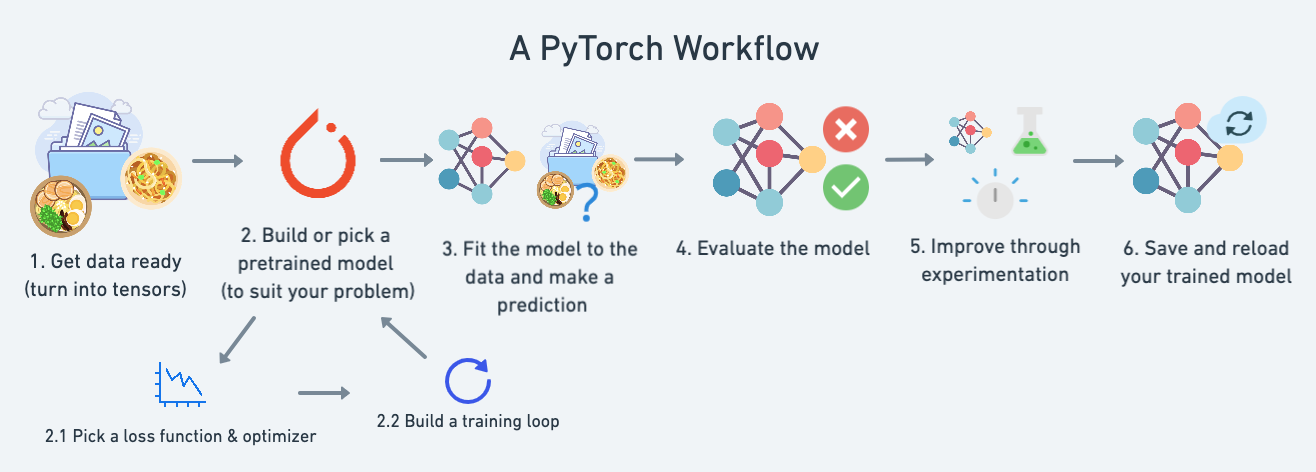

| Topic	| Contents | 
| ----- | -------- | 
| 1. **Getting data ready** |	Data can be almost anything but to get started we're going to create a simple straight line | |
| 2. **Building a model**	 | Here we'll create a model to learn patterns in the data, we'll also choose a loss function, optimizer and build a training loop. |
| 3. **Fitting the model to data (training)** |	We've got data and a model, now let's let the model (try to) find patterns in the (training) data. |
| 4. **Making predictions and evaluating a model (inference)** |	Our model's found patterns in the data, let's compare its findings to the actual (testing) data. |
| 5. **Saving and loading a model** |	To use your model elsewhere, or come back to it later. |
| 6. **Putting it all together** |	Let's take all of the above and combine it. |

In [1]:
# importing packages

import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.7.1'

## 1. Data (preparing and loading)

- A table of numbers (like a big Excel spreadsheet)
- images of any kind
- videos (YouTube has lots of data!)
- audio files like songs or podcasts
- protein structures
- text and more.

Machine learning is a game of two parts:

- Turn your data, whatever it is, into numbers (a representation).
- Pick or build a model to learn the representation as best as possible.

In [2]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Split data into training and test sets

We've got some data.

But before we build a model we need to split it up.

One of most important steps in a machine learning project is creating a training and test set (and when required, a validation set).

Each split of the dataset serves a specific purpose:

| Split	| Purpose	| Amount of total data | How often is it used? |
| ----- | ------- | -------------------- | --------------------- |
| **Training set** | The model learns from this data. | ~60-80%	| Always |`
| **Validation set** | The model gets tuned on this data. |	~10-20%	| Often but not always |
| **Testing set**	| The model gets evaluated on this data to test what it has learned. | ~10-20% | Always |

> **Note:** When dealing with real-world data, this step is typically done right at the start of a project (the test set should always be kept separate from all other data). We want our model to learn from training data and then evaluate it on test data to get an indication of how well it **generalizes** to unseen examples.

In [3]:
# create train/test split

train_split = int(0.8 * len(X)) # 80% of data for training, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [4]:
def plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=None,
):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

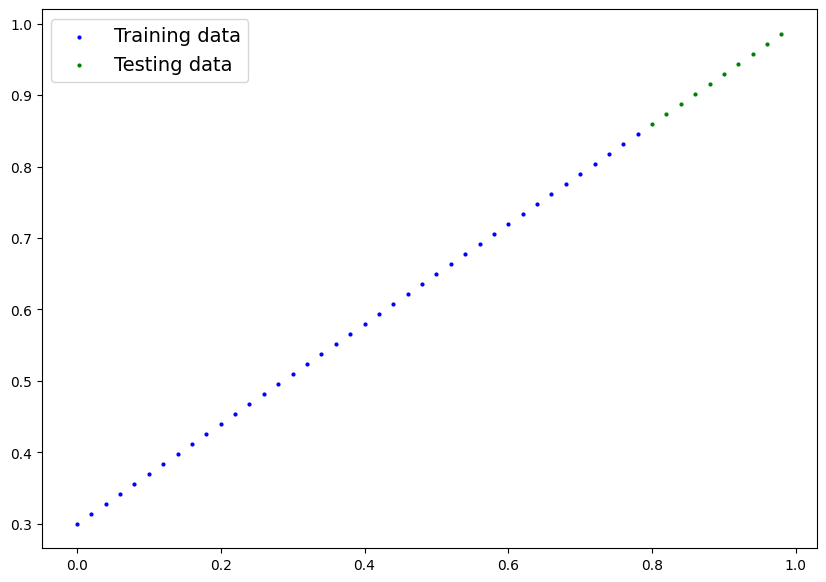

In [5]:
plot_predictions()

## 2. Build Model

In [6]:
# Create a Linear Regression model class
class LinearRegressionModel(
    nn.Module
):  # <- almost everything in PyTorch is a nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.randn(
                1,  # <- start with random weights (this will get adjusted as the model learns)
                dtype=torch.float,
            ), 
            requires_grad=True,
        )  # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(
            torch.randn(
                1,  # <- start with random bias (this will get adjusted as the model learns)
                dtype=torch.float,
            ), 
            requires_grad=True,
        )  # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(
        self, x: torch.Tensor
    ) -> torch.Tensor:  # <- "x" is the input data (e.g. training/testing features)
        return (
            self.weights * x + self.bias
        )  # <- this is the linear regression formula (y = m*x + b)


#### PyTorch model building essentials

PyTorch has four essential modules you can use to create almost any kind of neural network.

They are `torch.nn`, `torch.optim`, `torch.utils.data.Dataset` and `torch.utils.data.DataLoader`.

| PyTorch module | What does it do? |
| -------------- | ---------------- |
| `torch.nn` | Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way). |
| `torch.nn.Parameter` | Stores tensors that can be used with `nn.Module`. If `requires_grad=True` gradients (used for updating model parameters via **gradient descent**) are calculated automatically, this is often referred to as "autograd". |
| `torch.nn.Module` | The base class for all neural network modules, all the building blocks for neural networks are subclasses. If you're building a neural network in PyTorch, your models should subclass nn.Module. Requires a forward() method be implemented. |
| `torch.optim` | Contains various optimization algorithms (these tell the model parameters stored in nn.Parameter how to best change to improve gradient descent and in turn reduce the loss). |
| `def forward()` |	All nn.Module subclasses require a forward() method, this defines the computation that will take place on the data passed to the particular nn.Module (e.g. the linear regression formula above). |

In [7]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using `torch.inference_mode()`

To check this we can pass it the test data `X_test` to see how closely it predicts `y_test`.

When we pass data to our model, it'll go through the model's `forward()` method and produce a result using the computation we've defined.

In [9]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

In [10]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")


Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


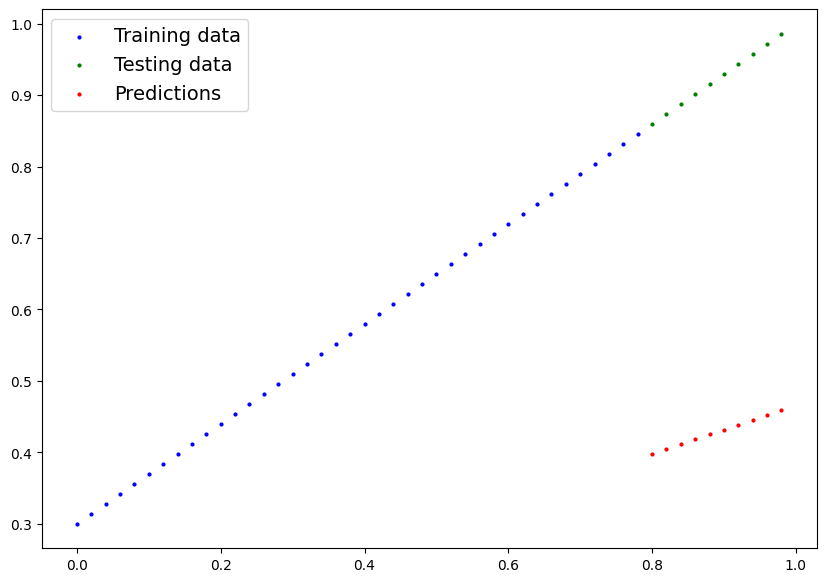

In [11]:
plot_predictions(predictions=y_preds)

In [12]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

The predictions are bad, as our model hasn't trained on the data.

## 3. Train Model

Right now our model is making predictions using random parameters to make calculations, it's basically guessing (randomly).

To fix that, we can update its internal parameters, the weights and bias values we set randomly using `nn.Parameter()` and `torch.randn()` to be something that better represents the data.

### Creating a loss function and optimizer in PyTorch

For our model to update its parameters on its own, we'll need to add a few more things to our recipe.

And that's a **loss function** as well as an **optimizer**.

Functions that are known to work well such as the **SGD** (stochastic gradient descent) or **Adam optimizer**. And the **MAE** (mean absolute error) loss function for regression problems (predicting a number) or **binary cross entropy** loss function for classification problems (predicting one thing or another).

In [13]:
# Create the loss function
loss_fn = nn.L1Loss()  # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
    params=model_0.parameters(),  # parameters of target model to optimize
    lr=0.01,
)  # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))


### Creating an optimization loop in PyTorch

#### PyTorch training loop

| Number | Step name | What does it do? | Code example |
| ------ | --------- | ---------------- | ------------ |
| 1 |	Forward pass | The model goes through all of the training data once, performing its forward() function calculations.	| `model(x_train)` |
| 2 |	Calculate the loss | The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are. | `loss = loss_fn(y_pred, y_train)` |
| 3 |	Zero gradients | The optimizers gradients are set to zero (they are accumulated by default) so they can be recalculated for the specific training step.	| `optimizer.zero_grad()` |
| 4 |	Perform backpropagation on the loss | Computes the gradient of the loss with respect for every model parameter to be updated (each parameter with requires_grad=True). This is known as backpropagation, hence "backwards".	| `loss.backward()` | 
| 5 |	Update the optimizer (gradient descent) | Update the parameters with requires_grad=True with respect to the loss gradients in order to improve them. | `optimizer.step()` |

#### PyTorch testing loop

| Number | Step name | What does it do? | Code example |
| ------ | --------- | ---------------- | ------------ |
| 1 |	Forward pass | The model goes through all of the testing data once, performing its forward() function calculations.	| `model(x_test)` |
| 2 |	Calculate the loss | The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are. | `loss = loss_fn(y_pred, y_test)` |
| 3 |	Calulate evaluation metrics | Alongside the loss value you may want to calculate other evaluation metrics such as accuracy on the test set.	| Custom functions |

In [14]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
        # 1. Forward pass on test data
        test_pred = model_0(X_test)

        # 2. Caculate loss on test data
        test_loss = loss_fn(
            test_pred, y_test.type(torch.float)
        )  # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

        # Print out what's happening
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(
                f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} "
            )


Epoch: 0 | MAE Train Loss: 0.31288135051727295 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713389158249 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.2172965705394745 
Epoch: 30 | MAE Train Loss: 0.053148530423641205 | MAE Test Loss: 0.14464019238948822 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953748226166 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633813381195 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937722325325 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.027887403964996338 | MAE Test Loss: 0.06473556160926819 


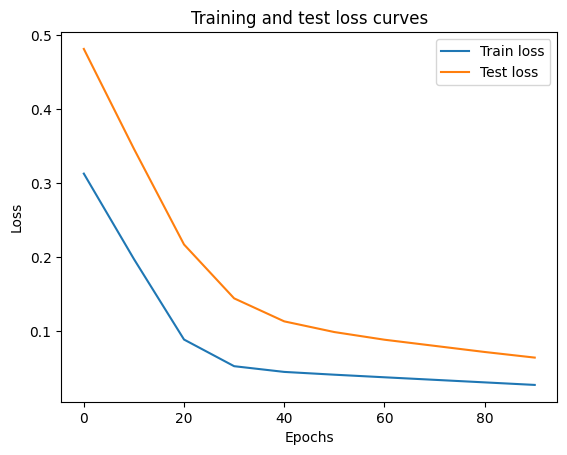

In [15]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()


In [16]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.5784]), 'bias': tensor([0.3513])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


Model got very close to actual `weight` and `bias`, we we increase the `epoch's` the model might get even closer.

In [17]:
def train_model(model, X, y, optimizer, loss_fn, epochs):
  for epoch in range(epochs):
      model.train()
      y_pred = model(X)
      loss = loss_fn(y_pred, y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
  return model

In [18]:
model_0 = train_model(model_0, X_train, y_train, optimizer, loss_fn, epochs=200)
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})


## 4. Making predictions with a trained PyTorch model (inference)

There are three things to remember when making predictions (also called performing inference) with a PyTorch model:

1. Set the model in evaluation mode (model.eval()).
2. Make the predictions using the inference mode context manager (with torch.inference_mode(): ...).
3. All predictions should be made with objects on the same device (e.g. data and model on GPU only or data and model on CPU only).

In [19]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
    # 3. Make sure the calculations are done with the model and data on the same device
    # in our case, we haven't setup device-agnostic code yet so our data and model are
    # on the CPU by default.
    # model_0.to(device)
    # X_test = X_test.to(device)
    y_preds = model_0(X_test)
y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

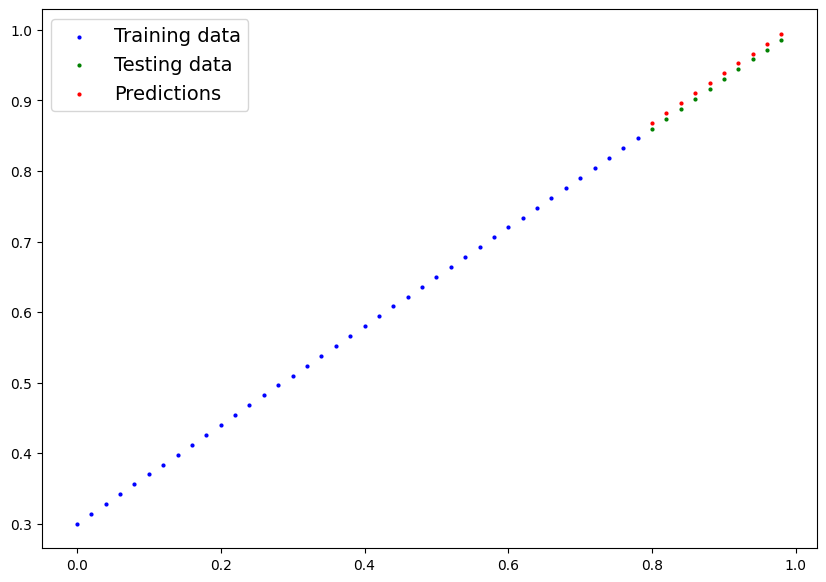

In [20]:
plot_predictions(predictions=y_preds)

## 5. Saving and loading a PyTorch model

| PyTorch method | What does it do? |
| -------------- | ---------------- |
| `torch.save`	| Saves a serialized object to disk using Python's pickle utility. Models, tensors and various other Python objects like dictionaries can be saved using `torch.save`. | 
| `torch.load`	| Uses pickle's unpickling features to deserialize and load pickled Python object files (like models, tensors or dictionaries) into memory. You can also set which device to load the object to (CPU, GPU etc). |
| `torch.nn.Module.load_state_dict` | Loads a model's parameter dictionary (model.state_dict()) using a saved `state_dict()` object. |

#### Saving a PyTorch model's `state_dict()`

The recommended way for saving and loading a model for inference (making predictions) is by saving and loading a model's `state_dict()`.

- We'll create a directory for saving models to called models using Python's `pathlib` module.
- We'll create a file path to save the model to.
- We'll call `torch.save(obj, f)` where `obj` is the target model's state_dict() and `f` is the filename of where to save the model.

In [21]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(
    obj=model_0.state_dict(),  # only saving the state_dict() only saves the models learned parameters
    f=MODEL_SAVE_PATH,
)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [22]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

-rw-r--r--@ 1 rahulsaini  staff  2117 Jun  7 17:53 models/01_pytorch_workflow_model_0.pth


#### Loading a saved PyTorch model's `state_dict()`

Since we've now got a saved model `state_dict()` at models/01_pytorch_workflow_model_0.pth we can now load it in using torch.nn.Module.load_state_dict(torch.load(f)) where f is the filepath of our saved model `state_dict()`.

Why call `torch.load()` inside `torch.nn.Module.load_state_dict()`?

Because we only saved the model's `state_dict()` which is a dictionary of learned parameters and not the entire model, we first have to load the `state_dict()` with torch.load() and then pass that `state_dict()` to a new instance of our model (which is a subclass of `nn.Module`).

Why not save the entire model?

The disadvantage of this approach (saving the whole model) is that the serialized data is bound to the specific classes and the exact directory structure used when the model is saved...

So instead, we're using the flexible method of saving and loading just the `state_dict()`, which again is basically a dictionary of model parameters.

In [23]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [24]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [25]:
# 1. Put the loaded model into evaluation mode
loaded_model_0.eval()

# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(
        X_test
    )  # perform a forward pass on the test data with the loaded model

In [26]:
# Compare previous model predictions with loaded model predictions (these should be the same)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting all together

In [27]:
# Import PyTorch and matplotlib
import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

In [28]:
device = ""
if torch.cuda.is_available():
    device = "cuda"  # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps"  # Use Apple Silicon GPU (if available)
else:
    device = "cpu"  # Default to CPU if no GPU is available

print(f"Using device: {device}")

Using device: mps


### 6.1 Data

In [29]:

# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(
    dim=1
)  # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [30]:
def plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=None,
):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})


### 6.2 Building a PyTorch linear model

In [31]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [32]:
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

### 6.3 Training

In [33]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(
    params=model_1.parameters(),  # optimize newly created model's parameters
    lr=0.01,
)

In [34]:
def train_model(model, X, y, optimizer, loss_fn, epochs):
  for epoch in range(epochs):
      model.train()
      y_pred = model(X)
      loss = loss_fn(y_pred, y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
  return model

In [35]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data on the available device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

In [36]:
model_1 = train_model(model_1, X_train, y_train, optimizer, loss_fn, epochs)
print("The model learned the following values for weights and bias:")
print(model_1.state_dict())

print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'linear_layer.weight': tensor([[0.6968]], device='mps:0'), 'linear_layer.bias': tensor([0.3025], device='mps:0')})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


### 6.4 Making predictions

In [37]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='mps:0')

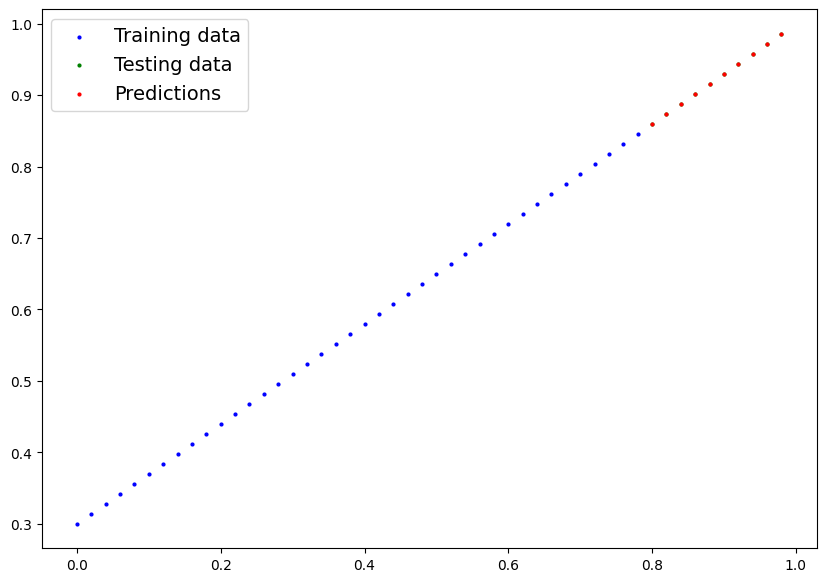

In [38]:
# Put data on the CPU and plot it
plot_predictions(predictions=y_preds.cpu())

### 6.5 Saving and loading a model

In [39]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(
    obj=model_1.state_dict(),  # only saving the state_dict() only saves the models learned parameters
    f=MODEL_SAVE_PATH,
)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [40]:
# Instantiate a fresh instance of LinearRegressionModelV2
loaded_model_1 = LinearRegressionModelV2()

# Load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
mps:0


In [41]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='mps:0')